In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import random
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
from kostyl.utils import dump_into_file
from kostyl.utils import load_file
from kostyl.utils import tqdm_rich
from PIL import Image
from plotly.colors import hex_to_rgb
from plotly.colors import qualitative
from plotly.subplots import make_subplots
from transformers import AutoImageProcessor
from transformers.models.dinov3_vit import DINOv3ViTModel

from vinishko.pipeline.steps.normalization.normalize import NormalizationReason
from vinishko.pipeline.steps.normalization.normalize import Normalizer
from vinishko.pipeline.steps.normalization.normalize import load_config
from vinishko.pipeline.steps.normalization.seg import open_image
from vinishko.pipeline.structs import Candidate
from vinishko.pipeline.structs import Rejection

In [2]:
config_path = Path(
    "/home/pomelk1n/Workspace/vinishko/vinishko/pipeline/steps/normalization/normalize.toml"
)

normalizer = Normalizer(load_config(config_path, overrides=[]), config_path.parent)

In [3]:
img_paths = list(
    Path(
        "/home/pomelk1n/Workspace/vinishko/datasets/visual-encoder/winesensed/images"
    ).iterdir()
)

In [4]:
import sys
from pathlib import Path


ROOT = Path("/home/pomelk1n/Workspace/vinishko")
sys.path.insert(0, str(ROOT))  # пакет не установлен, импорты идут от корня репозитория

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from vinishko.pipeline.steps.normalization.normalize import HERE as NORM_DIR
from vinishko.pipeline.steps.normalization.normalize import load_config
from vinishko.pipeline.steps.normalization.seg import open_image
from vis_seacher_training.configs import TrainingConfig
from vis_seacher_training.data.augmentations import TrainAugmenter
from vis_seacher_training.data.markup import index_markup
from vis_seacher_training.data.markup import read_candidate


cfg = TrainingConfig.from_file(
    ROOT / "vis_seacher_training/experiments/dinov3_vitb16_512/config.yaml"
).data
render_cfg = load_config(cfg.normalize_config or NORM_DIR / "normalize.toml", [])
spans: dict[
    str, tuple[int, int]
] = {}  # где в normalization.jsonl лежит строка картинки

# a = cfg.augmentations
# a.photometric.noise_prob = 1.0   # шум по всему кадру
# a.label_noise.prob = 1.0         # порча этикетки
# a.darkness.prob = 1.0            # полутьма
# for k in ("occlusion", "glare", "perspective"): getattr(a, k).prob = 0


def show_aug(
    winesensed_dir: str | Path, name: str, seed: int | None = None
) -> go.Figure:
    """Оригинальное фото и один случайный вид, как его получает модель на обучении; seed=None — каждый вызов новый вид."""
    root = Path(winesensed_dir)
    if name not in spans:
        spans.update(index_markup(root, {name}))
    if name not in spans:
        raise ValueError(
            f"{name}: нормализация не нашла годной бутылки, в обучение такая картинка не идёт"
        )
    rgb = np.asarray(open_image(root / "images" / name))
    seed = int(np.random.default_rng().integers(1 << 31)) if seed is None else seed
    image, offset = TrainAugmenter(cfg.augmentations, render_cfg, cfg.input_size, seed)(
        rgb, read_candidate(root, spans[name])
    )
    canvas = np.full(
        (*cfg.input_size, 3), np.round(np.array(cfg.img_mean) * 255), np.uint8
    )  # нулевые поля входа — цвет среднего
    top, left = (
        round((cfg.input_size[0] - image.shape[0]) * offset[0]),
        round((cfg.input_size[1] - image.shape[1]) * offset[1]),
    )
    canvas[top : top + image.shape[0], left : left + image.shape[1]] = image
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            f"оригинал {rgb.shape[1]}×{rgb.shape[0]}",
            f"аугментация, seed={seed}",
        ],
    )
    fig.add_trace(px.imshow(rgb).data[0], row=1, col=1)
    fig.add_trace(px.imshow(canvas).data[0], row=1, col=2)
    fig.update_xaxes(visible=False).update_yaxes(visible=False)
    return fig.update_layout(
        title=name, height=600, margin=dict(l=10, r=10, t=60, b=10)
    )

In [11]:
show_aug(
    Path("/home/pomelk1n/Workspace/vinishko/datasets/visual-encoder/winesensed"),
    random.choice(img_paths).name,
)

INFO     17:25:52.576 [markup.py] Индексирую /home/pomelk1n/Workspace/vinishko/datasets/visual-encoder/winesensed/normalization.jsonl: нужно 1 картинок


In [ ]:
REJECTED, LABEL_OK, LABEL_BAD = "#9aa0a6", "#ffd60a", "#ff375f"


def mask_trace(polys, name, color, hover, alpha=0.35, visible=True):
    """Маска заливкой с контуром; отдельная строка легенды, клик по ней скрывает маску."""
    xs, ys = [], []
    for p in polys:
        if len(p) >= 3:
            xs += [*(pt[0] for pt in p), p[0][0], None]
            ys += [*(pt[1] for pt in p), p[0][1], None]
    r, g, b = hex_to_rgb(color)
    return go.Scatter(
        x=xs,
        y=ys,
        name=name,
        mode="lines",
        fill="toself",
        fillcolor=f"rgba({r},{g},{b},{alpha})",
        line={"color": color, "width": 2},
        hoveron="fills",
        hoverinfo="text",
        text=hover,
        visible=True if visible else "legendonly",
    )


def item_traces(item, n):
    """Следы одной бутылки: годная — цветная маска и жёлтая этикетка; отказ — серая маска и красная этикетка, если она нашлась."""
    if isinstance(item, Candidate):
        color = qualitative.Plotly[(item.index - 1) % len(qualitative.Plotly)]
        hover = f"годная бутылка {item.index}<br>score {item.score}<br>угол {item.angle}°<br>uuid {item.uuid[:8]}"
        return [
            mask_trace(item.bottle, f"b{item.index} бутылка", color, hover),
            mask_trace(
                item.label,
                f"b{item.index} этикетка",
                LABEL_OK,
                f"b{item.index} основная этикетка",
            ),
        ]
    hover = f"{item.message}<br>score {item.score}<br><i>{item.reason.description}</i>"
    shown = (
        item.reason != NormalizationReason.NOT_TARGET
    )  # фоновые бутылки выключены до клика, отказы по этикетке видны сразу
    traces = [
        mask_trace(
            item.bottle,
            f"отказ {n} · {item.reason.title}",
            REJECTED,
            hover,
            visible=shown,
        )
    ]
    if item.label:
        traces.append(
            mask_trace(
                item.label, f"отказ {n} · этикетка", LABEL_BAD, hover, visible=shown
            )
        )
    return traces


def add_picture(fig, picture, col):
    """Картинка фоном своей колонки: оси в её пикселях, y вниз, пропорции сохраняются."""
    w, h = picture.size
    ref = "" if col == 1 else str(col)
    fig.add_layout_image(
        source=picture,
        x=0,
        y=0,
        sizex=w,
        sizey=h,
        xref=f"x{ref}",
        yref=f"y{ref}",
        xanchor="left",
        yanchor="top",
        sizing="stretch",
        layer="below",
    )
    fig.update_xaxes(range=[0, w], visible=False, constrain="domain", row=1, col=col)
    fig.update_yaxes(
        range=[h, 0],
        visible=False,
        scaleanchor=f"x{ref}",
        scaleratio=1,
        constrain="domain",
        row=1,
        col=col,
    )


def plot_normalization(
    image: Image.Image,
    samples: list | None,
    items: list,
    size: tuple[int, int] = (1200, 800),
) -> go.Figure:
    """Слева оригинал с масками всех найденных бутылок, справа кропы, которые идут дальше по пайплайну; size — ширина и высота графика.

    samples и items — пара, которую отдаёт normalizer(image). Если samples равен None, годных бутылок нет и справа пусто.
    Клик по строке легенды скрывает или показывает маску, двойной клик оставляет одну, кнопки сверху переключают все разом.
    """
    crops = [Image.fromarray(s.crop) for s in samples or []]
    pictures = [image, *crops]
    titles = [
        "оригинал",
        *(f"b{s.candidate.index} · в пайплайн · {s.uuid[:8]}" for s in samples or []),
    ]
    widths = [
        p.width / p.height for p in pictures
    ]  # при общей высоте ширина колонки пропорциональна отношению сторон
    fig = make_subplots(
        rows=1,
        cols=len(pictures),
        column_widths=widths,
        subplot_titles=titles,
        horizontal_spacing=0.02,
    )
    for col, picture in enumerate(pictures, 1):
        add_picture(fig, picture, col)
    for n, item in enumerate(items, 1):
        fig.add_traces(item_traces(item, n), rows=1, cols=1)
    buttons = [
        {"label": "все маски", "method": "restyle", "args": [{"visible": True}]},
        {
            "label": "только фото",
            "method": "restyle",
            "args": [{"visible": "legendonly"}],
        },
    ]
    n_ok = sum(isinstance(item, Candidate) for item in items)
    fig.update_layout(
        width=size[0],
        height=size[1],
        title={
            "text": f"годных {n_ok} · отказов {len(items) - n_ok}"
            + ("" if samples else " · в пайплайн ничего не идёт"),
            "y": 0.99,
            "yanchor": "top",
        },
        margin={"l": 10, "r": 10, "t": 120, "b": 10},
        legend={"itemclick": "toggle", "itemdoubleclick": "toggleothers"},
        updatemenus=[
            {
                "type": "buttons",
                "direction": "right",
                "x": 0,
                "xanchor": "left",
                "y": 1.06,
                "yanchor": "bottom",
                "buttons": buttons,
            }
        ],
        hoverlabel={"align": "left"},
    )
    return fig

In [ ]:
path = random.choice(img_paths)
# path = Path("/home/pomelk1n/Workspace/vinishko/datasets/visual-encoder/off/images/8411767281144.jpg")
image = open_image(str(path))
samples, items = normalizer(image)
plot_normalization(image, samples, items, size=(1200, 800))

Ultralytics 8.4.154 🚀 Python-3.13.7 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080, 9926MiB)


In [5]:
path = random.choice(img_paths)
image = open_image(str(path))
image.size

(480, 640)

In [2]:
pretrained_model_name = "facebook/dinov3-vitl16-pretrain-lvd1689m"
model = DINOv3ViTModel.from_pretrained(pretrained_model_name, token=True)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [3]:
model._no_split_modules

{'DINOv3ViTLayer'}

In [6]:
512 / 16

32.0

In [5]:
model.config

DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 1024,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "key_bias": false,
  "layer_norm_eps": 1e-05,
  "layerscale_value": 1.0,
  "mlp_bias": true,
  "model_type": "dinov3_vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "num_register_tokens": 4,
  "out_features": [
    "stage24"
  ],
  "out_indices": [
    24
  ],
  "patch_size": 16,
  "pos_embed_jitter": null,
  "pos_embed_rescale": 2.0,
  "pos_embed_shift": null,
  "proj_bias": true,
  "query_bias": true,
  "reshape_hidden_states": true,
  "rope_theta": 100.0,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12",
   

In [24]:
processor = AutoImageProcessor.from_pretrained(pretrained_model_name, size=(512, 512))
processor

DINOv3ViTImageProcessor {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 512,
    "width": 512
  }
}

In [25]:
model.config

DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 1024,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "key_bias": false,
  "layer_norm_eps": 1e-05,
  "layerscale_value": 1.0,
  "mlp_bias": true,
  "model_type": "dinov3_vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "num_register_tokens": 4,
  "out_features": [
    "stage24"
  ],
  "out_indices": [
    24
  ],
  "patch_size": 16,
  "pos_embed_jitter": null,
  "pos_embed_rescale": 2.0,
  "pos_embed_shift": null,
  "proj_bias": true,
  "query_bias": true,
  "reshape_hidden_states": true,
  "rope_theta": 100.0,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12",
   

In [ ]:
input_size = 512, 512
IMAGE_NET_MEAN = np.round(np.array([0.485, 0.456, 0.406]) * 255).astype(np.uint8)

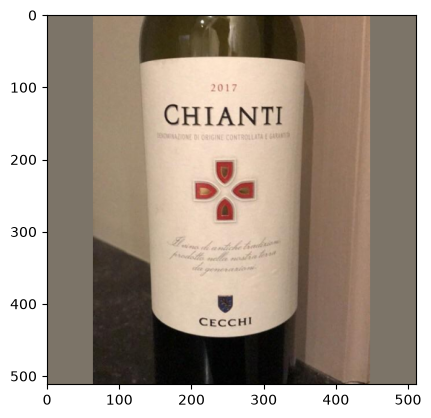

In [ ]:
img_np = np.array(image)
canvas = np.ones((input_size[1], input_size[0], 3), dtype=np.uint8) * IMAGE_NET_MEAN
s = min(input_size[0] / img_np.shape[1], input_size[1] / img_np.shape[0])

resized_w, resized_h = int(s * img_np.shape[1]), int(s * img_np.shape[0])
resized_img = cv2.resize(img_np, (resized_w, resized_h), interpolation=cv2.INTER_LINEAR)

x_offset = (input_size[0] - resized_w) // 2
y_offset = (input_size[1] - resized_h) // 2

canvas[y_offset : y_offset + resized_h, x_offset : x_offset + resized_w] = resized_img

img = Image.fromarray(canvas)

plt.imshow(img)

In [23]:
processor

DINOv3ViTImageProcessor {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [ ]:
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)

In [7]:
model.config

DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 1024,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "key_bias": false,
  "layer_norm_eps": 1e-05,
  "layerscale_value": 1.0,
  "mlp_bias": true,
  "model_type": "dinov3_vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "num_register_tokens": 4,
  "out_features": [
    "stage24"
  ],
  "out_indices": [
    24
  ],
  "patch_size": 16,
  "pos_embed_jitter": null,
  "pos_embed_rescale": 2.0,
  "pos_embed_shift": null,
  "proj_bias": true,
  "query_bias": true,
  "reshape_hidden_states": true,
  "rope_theta": 100.0,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12",
   

In [15]:
items

[Rejection(reason=<NormalizationReason.LABEL_BLURRY: 'label_blurry'>, detail='резкость 206, нужно от 300', score=0.8755, bottle=[[[23, 0], [19, 3], [18, 6], [19, 59], [21, 69], [19, 118], [19, 174], [21, 199], [21, 237], [23, 246], [22, 254], [25, 319], [24, 335], [26, 353], [25, 376], [27, 387], [26, 405], [27, 418], [29, 424], [28, 449], [30, 465], [30, 510], [32, 524], [33, 557], [37, 581], [42, 596], [52, 614], [74, 637], [100, 637], [102, 639], [108, 637], [115, 639], [123, 637], [135, 639], [139, 637], [224, 637], [229, 639], [237, 637], [248, 639], [253, 637], [274, 637], [276, 639], [282, 637], [289, 639], [293, 637], [296, 639], [306, 639], [314, 637], [334, 637], [359, 639], [362, 637], [392, 637], [407, 632], [420, 623], [421, 620], [430, 610], [432, 604], [437, 597], [437, 594], [440, 590], [440, 585], [444, 578], [448, 548], [448, 495], [450, 485], [450, 438], [448, 434], [448, 413], [450, 412], [450, 385], [447, 381], [448, 367], [445, 365], [447, 361], [447, 348], [445, 

In [20]:
items[0].label

[[[54, 113],
  [51, 116],
  [51, 163],
  [57, 411],
  [59, 439],
  [59, 507],
  [61, 515],
  [61, 533],
  [68, 538],
  [91, 546],
  [117, 553],
  [134, 555],
  [138, 557],
  [192, 563],
  [252, 564],
  [272, 562],
  [294, 562],
  [363, 552],
  [398, 542],
  [425, 531],
  [428, 526],
  [428, 441],
  [430, 435],
  [429, 396],
  [431, 329],
  [430, 310],
  [432, 162],
  [431, 116],
  [420, 111],
  [372, 101],
  [346, 99],
  [338, 97],
  [305, 96],
  [290, 94],
  [202, 94],
  [149, 97],
  [143, 99],
  [131, 99],
  [101, 104],
  [93, 104]]]

In [9]:
image.size

(480, 640)